## **Introduction**
International trade continues to play a crucial role in Europe’s economic performance, competitiveness, and strategic positioning in global markets. For European Trade Union's policymakers, understanding how strongly European economies rely on international trade, and how this reliance varies across countries and product categories, is essential for designing resilient and forward-looking trade policies (Hristanova, 2025).

This project uses GDP data and international trade statistics from 2020 to assess Europe’s trade structure and identify which countries within the region are most dependent on international trade. The report evaluates trade dependency, covering both import and export activity, and investigates how trade is distributed across major product categories (including raw materials, intermediate goods, consumer goods, and capital goods).

By integrating economic indicators with detailed trade data, the project enhances understanding of Europe’s trade dependencies and the economic characteristics of its most trade-driven countries. These insights contribute to evidence-based discussions on economic resilience, trade diversification, and policy priorities in a rapidly evolving global environment.

## **Data Sourcing, Auditing, and Wrangling**

### **Dataset 1 – GDP Among Countries** [link](https://drive.google.com/drive/folders/1U4W2cwR7Z24wbuvpNV1HDCE-HH8v5NKD?usp=drive_link)
- **Source:** [https://www.kaggle.com/darknez/gdp-among-world](https://www.kaggle.com/darknez/gdp-among-world)  
- **Format:** CSV file  
- **Characteristics:** Tabular form with 184 rows and 18 columns  

#### Initial Audit
Overall, the dataset is clean and complete, except for the Anthem and Government columns. However, this information is not relevant to the research. Additionally, the GDP units are inconsistent; some values are recorded in billions while others are in millions, requiring normalisation for meaningful comparison.  

#### Transformation
The data transformation process involved several key steps to prepare the dataset for analysis:

1. **Column Selection:** Unnecessary columns were removed to retain only the relevant ones: country, region, GDP, and GDP per capita.  
2. **Missing Values Check:** Missing values were checked to ensure data completeness and reliability.  
3. **Data Cleaning:** GDP-related columns were cleaned by removing dollar signs and commas, followed by converting the values into numeric form to enable calculations.  
4. **Unit Standardisation:** All GDP figures were converted to millions to standardise the units.  
5. **Country Code Mapping:** A country-to-country-code dictionary was created, and the country code column was added to the dataframe. This allowed records to be matched based on the official ISO3A code of each country, facilitating easier data merging


In [ ]:
import pandas as pd

# loading the gdp dataset into the dataframe
df_gdp = pd.read_csv("GDP.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'GDP.csv'

In [ ]:
# inspecting the dataset with info function
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                184 non-null    object 
 1   Population Rank        182 non-null    float64
 2   Growth Rate            182 non-null    object 
 3   World Percentage       182 non-null    object 
 4   Density                184 non-null    float64
 5   Land Area              182 non-null    object 
 6   2020 Population Rank   184 non-null    int64  
 7   2020 World Percentage  184 non-null    object 
 8   2020 Growth Rate       184 non-null    object 
 9   Area                   184 non-null    object 
 10  Capital City           184 non-null    object 
 11  Region                 184 non-null    object 
 12  Subregion              184 non-null    object 
 13  Anthem                 26 non-null     object 
 14  Government             78 non-null     object 
 15  GDP (I

In [ ]:
# understand
print(df_gdp[df_gdp["Population Rank"].isna()])

        Country  Population Rank Growth Rate World Percentage  Density  \
7         Sudan              NaN         NaN              NaN    23.25   
67  South Sudan              NaN         NaN              NaN    18.06   

   Land Area  2020 Population Rank 2020 World Percentage 2020 Growth Rate  \
7        NaN                    34                 0.56%            2.42%   
67       NaN                    84                 0.14%            1.19%   

         Area Capital City  Region        Subregion Anthem Government  \
7   1,886,068     Khartoum  Africa  Northern Africa    NaN      Sudan   
67    619,745         Juba  Africa    Middle Africa    NaN        NaN   

   GDP (IMF)   GDP (UN) GDP Per Capita  
7          -  $82.89 Bn      $1,890.28  
67  $2.80 Bn   $6.53 Bn        $249.78  


In [ ]:
# List of columns to drop
columns_to_drop = [
    'Population Rank', 'Growth Rate', 'World Percentage', 'Density', 'Land Area',
    '2020 Population Rank', '2020 World Percentage', '2020 Growth Rate',
    'Capital City', 'Subregion', 'Anthem', 'Government','Area','GDP (IMF)'
]

# Remove tthe unnecessary columns from our dataset
df_gdp = df_gdp.drop(columns=columns_to_drop)

# Preview the cleaned data
print(df_gdp.head())

      Country  Region   GDP (UN) GDP Per Capita
0       Japan    Asia   $4.94 Tn     $43,450.14
1  Mauritania  Africa   $4.67 Bn      $1,225.25
2  Cape Verde  Africa   $1.64 Bn      $3,971.32
3     Tunisia  Africa  $41.70 Bn      $2,974.12
4     Eritrea  Africa   $5.41 Bn       $2,288.5


In [ ]:
# check for missing values per column after removing unnesarry columns
missing_counts = df_gdp.isnull().sum()
print(missing_counts)

# no missing values found after removing unnessary columns

Country           0
Region            0
GDP (UN)          0
GDP Per Capita    0
dtype: int64


In [ ]:
# remove dollar signs and commas in GDP per Capita , and convert into numeric format
df_gdp['GDP Per Capita'] = df_gdp['GDP Per Capita'].replace(r'[\$,]', '', regex=True).replace(',', '', regex=True)

df_gdp['GDP Per Capita'] = pd.to_numeric(df_gdp['GDP Per Capita'], errors='coerce')

In [ ]:
# remove symbols (dollar signs and commas) from GDP values and convert the unit into millions

def normalize_gdp_to_millions(value):
    if pd.isnull(value):
        return None
    value = value.replace('$', '').replace(',', '').strip()
    if 'Tn' in value:
        return float(value.replace('Tn', '')) * 1000000
    elif 'Bn' in value:
        return float(value.replace('Bn', '')) * 1000
    elif 'Mn' in value:
        return float(value.replace('Mn', ''))
    else:
        return None

df_gdp['UN GDP ($USD, Million)'] = df_gdp['GDP (UN)'].apply(normalize_gdp_to_millions)

print(df_gdp.head())


      Country  Region   GDP (UN)  GDP Per Capita  UN GDP ($USD, Million)
0       Japan    Asia   $4.94 Tn        43450.14               4940000.0
1  Mauritania  Africa   $4.67 Bn         1225.25                  4670.0
2  Cape Verde  Africa   $1.64 Bn         3971.32                  1640.0
3     Tunisia  Africa  $41.70 Bn         2974.12                 41700.0
4     Eritrea  Africa   $5.41 Bn         2288.50                  5410.0


In [ ]:
# create a dictionary mapping country names to ISO3A codes (internationally standardised identification of countries)
country_to_iso3 = {
    "Afghanistan": "AFG",
    "Albania": "ALB",
    "Algeria": "DZA",
    "Andorra": "AND",
    "Angola": "AGO",
    "Antigua and Barbuda": "ATG",
    "Argentina": "ARG",
    "Armenia": "ARM",
    "Aruba": "ABW",
    "Australia": "AUS",
    "Austria": "AUT",
    "Azerbaijan": "AZE",
    "Bahamas": "BHS",
    "Bahrain": "BHR",
    "Bangladesh": "BGD",
    "Barbados": "BRB",
    "Belarus": "BLR",
    "Belgium": "BEL",
    "Belize": "BLZ",
    "Benin": "BEN",
    "Bhutan": "BTN",
    "Bolivia": "BOL",
    "Bosnia and Herzegovina": "BIH",
    "Botswana": "BWA",
    "Brazil": "BRA",
    "Brunei": "BRN",
    "Bulgaria": "BGR",
    "Burkina Faso": "BFA",
    "Burundi": "BDI",
    "Cabo Verde": "CPV",
    "Cambodia": "KHM",
    "Cameroon": "CMR",
    "Canada": "CAN",
    "Central African Republic": "CAF",
    "Chad": "TCD",
    "Chile": "CHL",
    "China": "CHN",
    "Colombia": "COL",
    "Comoros": "COM",
    "Congo (Brazzaville)": "COG",
    "Congo (Kinshasa)": "COD",
    "Costa Rica": "CRI",
    "Croatia": "HRV",
    "Cuba": "CUB",
    "Cyprus": "CYP",
    "Czech Republic": "CZE",
    "Denmark": "DNK",
    "Djibouti": "DJI",
    "Dominica": "DMA",
    "Dominican Republic": "DOM",
    "Ecuador": "ECU",
    "Egypt": "EGY",
    "El Salvador": "SLV",
    "Equatorial Guinea": "GNQ",
    "Eritrea": "ERI",
    "Estonia": "EST",
    "Eswatini": "SWZ",
    "Ethiopia": "ETH",
    "Fiji": "FJI",
    "Finland": "FIN",
    "France": "FRA",
    "Gabon": "GAB",
    "Gambia": "GMB",
    "Georgia": "GEO",
    "Germany": "DEU",
    "Ghana": "GHA",
    "Greece": "GRC",
    "Grenada": "GRD",
    "Guatemala": "GTM",
    "Guinea": "GIN",
    "Guinea-Bissau": "GNB",
    "Guyana": "GUY",
    "Haiti": "HTI",
    "Honduras": "HND",
    "Hungary": "HUN",
    "Iceland": "ISL",
    "India": "IND",
    "Indonesia": "IDN",
    "Iran": "IRN",
    "Iraq": "IRQ",
    "Ireland": "IRL",
    "Israel": "ISR",
    "Italy": "ITA",
    "Ivory Coast": "CIV",
    "Jamaica": "JAM",
    "Japan": "JPN",
    "Jordan": "JOR",
    "Kazakhstan": "KAZ",
    "Kenya": "KEN",
    "Kiribati": "KIR",
    "Kuwait": "KWT",
    "Kyrgyzstan": "KGZ",
    "Laos": "LAO",
    "Latvia": "LVA",
    "Lebanon": "LBN",
    "Lesotho": "LSO",
    "Liberia": "LBR",
    "Libya": "LBY",
    "Liechtenstein": "LIE",
    "Lithuania": "LTU",
    "Luxembourg": "LUX",
    "Madagascar": "MDG",
    "Malawi": "MWI",
    "Malaysia": "MYS",
    "Maldives": "MDV",
    "Mali": "MLI",
    "Malta": "MLT",
    "Marshall Islands": "MHL",
    "Mauritania": "MRT",
    "Mauritius": "MUS",
    "Mexico": "MEX",
    "Micronesia": "FSM",
    "Moldova": "MDA",
    "Monaco": "MCO",
    "Mongolia": "MNG",
    "Montenegro": "MNE",
    "Morocco": "MAR",
    "Mozambique": "MOZ",
    "Myanmar": "MMR",
    "Namibia": "NAM",
    "Nauru": "NRU",
    "Nepal": "NPL",
    "Netherlands": "NLD",
    "New Zealand": "NZL",
    "Nicaragua": "NIC",
    "Niger": "NER",
    "Nigeria": "NGA",
    "North Macedonia": "MKD",
    "Norway": "NOR",
    "Oman": "OMN",
    "Pakistan": "PAK",
    "Palau": "PLW",
    "Panama": "PAN",
    "Papua New Guinea": "PNG",
    "Paraguay": "PRY",
    "Peru": "PER",
    "Philippines": "PHL",
    "Poland": "POL",
    "Portugal": "PRT",
    "Qatar": "QAT",
    "Romania": "ROU",
    "Russia": "RUS",
    "Rwanda": "RWA",
    "Saint Kitts and Nevis": "KNA",
    "Saint Lucia": "LCA",
    "Saint Vincent and the Grenadines": "VCT",
    "Samoa": "WSM",
    "San Marino": "SMR",
    "Sao Tome and Principe": "STP",
    "Saudi Arabia": "SAU",
    "Senegal": "SEN",
    "Serbia": "SRB",
    "Seychelles": "SYC",
    "Sierra Leone": "SLE",
    "Singapore": "SGP",
    "Slovakia": "SVK",
    "Slovenia": "SVN",
    "Solomon Islands": "SLB",
    "Somalia": "SOM",
    "South Africa": "ZAF",
    "South Korea": "KOR",
    "South Sudan": "SSD",
    "Spain": "ESP",
    "Sri Lanka": "LKA",
    "Sudan": "SDN",
    "Suriname": "SUR",
    "Sweden": "SWE",
    "Switzerland": "CHE",
    "Syria": "SYR",
    "Taiwan": "TWN",
    "Tajikistan": "TJK",
    "Tanzania": "TZA",
    "Thailand": "THA",
    "Timor-Leste": "TLS",
    "Togo": "TGO",
    "Tonga": "TON",
    "Trinidad and Tobago": "TTO",
    "Tunisia": "TUN",
    "Turkey": "TUR",
    "Turkmenistan": "TKM",
    "Tuvalu": "TUV",
    "Uganda": "UGA",
    "Ukraine": "UKR",
    "United Arab Emirates": "ARE",
    "United Kingdom": "GBR",
    "United States": "USA",
    "Uruguay": "URY",
    "Uzbekistan": "UZB",
    "Vanuatu": "VUT",
    "Vatican City": "VAT",
    "Venezuela": "VEN",
    "Vietnam": "VNM",
    "Yemen": "YEM",
    "Zambia": "ZMB",
    "Zimbabwe": "ZWE",
    "DR Congo": "COD",
    "Ivory Coast": "CIV",
    "South Korea": "KOR",
    "North Korea": "PRK",
    "Czech Republic": "CZE",
    "Taiwan": "TWN",
    "Russia": "RUS",
    "United States": "USA",
    "United Kingdom": "GBR",
    "Vatican City": "VAT",
    "Syria": "SYR",
    "Micronesia": "FSM",
    "Brunei": "BRN",
    "Cape Verde": "CPV",
    "Sao Tome and Principe": "STP",
    "South Sudan": "SSD",
    "Myanmar": "MMR",
    "Republic of the Congo": "COG",
    "Swaziland": "SWZ",
    "North Macedonia": "MKD",
    "Macedonia": "MKD",
    "Puerto Rico": "PRI"
}


# add new country code column into the dataframe using the dictionary
df_gdp["Country_Code"] = df_gdp["Country"].map(country_to_iso3)

# inspect updated dataframe
print(df_gdp.head())


      Country  Region   GDP (UN)  GDP Per Capita  UN GDP ($USD, Million)  \
0       Japan    Asia   $4.94 Tn        43450.14               4940000.0   
1  Mauritania  Africa   $4.67 Bn         1225.25                  4670.0   
2  Cape Verde  Africa   $1.64 Bn         3971.32                  1640.0   
3     Tunisia  Africa  $41.70 Bn         2974.12                 41700.0   
4     Eritrea  Africa   $5.41 Bn         2288.50                  5410.0   

  Country_Code  
0          JPN  
1          MRT  
2          CPV  
3          TUN  
4          ERI  


In [ ]:
# check for missing values in the new country code column
missing_iso3a = df_gdp[df_gdp["Country_Code"].isna()]

print("Countries with missing ISO3A codes:")
print(missing_iso3a["Country"].unique())


Countries with missing ISO3A codes:
[]


## **Dataset 2 – WTO Stats** [link](https://drive.google.com/drive/folders/1U4W2cwR7Z24wbuvpNV1HDCE-HH8v5NKD?usp=drive_link)
- **Source:** [https://stats.wto.org/inventory/en](https://stats.wto.org/inventory/en)  
- **Format:** XLSX file  
- **Characteristics:** Tabular form with 6,230 rows and 24 columns  

### Initial Audit  
The dataset is complete with values that are relevant for analysis. However, the export and import data need to be pivoted to columns (wide format) from rows (long format) for analysis.  

### Transformation  
The data transformation process involved several key cleaning and restructuring steps to prepare the dataset for analysis:

1. **Column Selection:** Unnecessary columns were removed, retaining only relevant data such as country, country code, year, indicator type, and trade value.  
2. **Standardisation:** The indicator type values were standardised to clearly represent “import” or “export” for better readability.  
3. **Pivot Table:** A pivot table reshaped the data into a wide format, separating imports and exports into two columns for individual countries.  
4. **Column Renaming:** These columns were renamed for clarity, and their numeric values were rounded to two decimal places for a cleaner presentation.  
5. **Total Trade:** A new column, ‘Total Trade’, was created by summing the import and export values for analysis.  
6. **Data Filtering:** Finally, the dataset was filtered to include only records from the year 2020, ensuring consistency with the GDP data available for that year.


In [ ]:
import pandas as pd
import numpy as np

trade_data = pd.read_excel("Dataset_International_Trade.xlsx")


In [ ]:
 # inspect the first few rows to see data structure and column names
print("\n--- 2a. First 5 Rows (Head) ---")
print(trade_data.head().to_markdown(index=False))

# inspect the number of rows and columns (Shape)
print("\n--- 2b. Data Shape (Rows, Columns) ---")
print(trade_data.shape)

# inspect column names, non-null counts, and data types (Info)
print("\n--- 2c. Column Data Types and Non-Null Counts (Info) ---")
trade_data.info()

# inspect unique values in the key linking column 'Reporting Economy ISO3A Code'
print("\n--- 3a. Unique Count for Reporting Economy ISO3A Code ---")
print(f"Number of unique country codes (Reporting Economy ISO3A Code): {trade_data['Reporting Economy ISO3A Code'].nunique()}")

# inspect unique values in 'Indicator' to see if it needs filtering/pivoting
print("\n--- 3b. Unique Values in 'Indicator' ---")
print(trade_data['Indicator'].value_counts().to_markdown())

# inspect the 'Unit' column to confirm all values are consistent
print("\n--- 3c. Unique Values in 'Unit' ---")
print(trade_data['Unit'].value_counts().to_markdown())


--- 2a. First 5 Rows (Head) ---
| Indicator Category       | Indicator Code   | Indicator                                     |   Reporting Economy Code | Reporting Economy ISO3A Code   | Reporting Economy   |   Partner Economy Code |   Partner Economy ISO3A Code | Partner Economy   | Product/Sector Classification Code   | Product/Sector Classification              | Product/Sector Code   | Product/Sector    | Period Code   | Period   | Frequency Code   | Frequency   | Unit Code   | Unit              |   Year |   Value Flag Code |   Value Flag |   Text Value |   Value |
|:-------------------------|:-----------------|:----------------------------------------------|-------------------------:|:-------------------------------|:--------------------|-----------------------:|-----------------------------:|:------------------|:-------------------------------------|:-------------------------------------------|:----------------------|:------------------|:--------------|:---------|:-------------

In [ ]:
# Dropping unwanted columns
columns_to_keep = [
'Reporting Economy ISO3A Code',
'Reporting Economy',
'Year',
'Indicator',
'Value'
    ]

trade_data_filtered = trade_data[columns_to_keep].copy()

 # Clean column names for consistency with the other datasets
trade_data_filtered.rename(columns={
'Reporting Economy ISO3A Code': 'Country_Code',
'Reporting Economy': 'Country',
'Year': 'Year',
'Indicator': 'Indicator_Type',
'Value': 'Trade_Value_USM' # USM = Million US Dollars
    }, inplace=True)

print(f"Shape after column selection: {trade_data_filtered.shape}")
print(trade_data_filtered.head().to_markdown(index=False))

Shape after column selection: (6230, 5)
| Country_Code   | Country     |   Year | Indicator_Type                                |   Trade_Value_USM |
|:---------------|:------------|-------:|:----------------------------------------------|------------------:|
| AFG            | Afghanistan |   2005 | Merchandise imports by product group ñ annual |           2470.74 |
| AFG            | Afghanistan |   2010 | Merchandise imports by product group ñ annual |           5154.25 |
| AFG            | Afghanistan |   2011 | Merchandise imports by product group ñ annual |           6515    |
| AFG            | Afghanistan |   2014 | Merchandise imports by product group ñ annual |           7729.17 |
| AFG            | Afghanistan |   2013 | Merchandise imports by product group ñ annual |           8554.41 |


In [ ]:
#transforming the Indicator_type column
def clean_indicator_type(indicator_string):

    indicator_string = str(indicator_string).lower()
    if 'imports' in indicator_string:
        return 'Merchandise imports'
    elif 'exports' in indicator_string:
        return 'Merchandise exports'
    return indicator_string

trade_data_filtered['Indicator_Type'] = trade_data_filtered['Indicator_Type'].apply(clean_indicator_type)
trade_data_filtered

,Country_Code,Country,Year,Indicator_Type,Trade_Value_USM
0,AFG,Afghanistan,2005,Merchandise imports,2470.740000
1,AFG,Afghanistan,2010,Merchandise imports,5154.250000
2,AFG,Afghanistan,2011,Merchandise imports,6515.000000
3,AFG,Afghanistan,2014,Merchandise imports,7729.168790
4,AFG,Afghanistan,2013,Merchandise imports,8554.414000
...,...,...,...,...,...
6225,ZMB,Zambia,2014,Merchandise exports,9694.202351
6226,ZMB,Zambia,2015,Merchandise exports,6606.513175
6227,ZMB,Zambia,2013,Merchandise exports,10606.851708
6228,ZMB,Zambia,2010,Merchandise exports,7200.267000


In [ ]:
# transform dataframe from long format into wide format
trade_data_pivot = trade_data_filtered.pivot_table(
        index=['Country_Code', 'Country', 'Year'],
        columns='Indicator_Type',
        values='Trade_Value_USM'
    ).reset_index()

trade_data_pivot.columns.name = None

# Rename columns for clarity post-pivot
trade_data_pivot.rename(columns={
    'Merchandise imports': 'Imports_USM',
    'Merchandise exports': 'Exports_USM'
}, inplace=True)
trade_data_pivot

,Country_Code,Country,Year,Exports_USM,Imports_USM
0,AFG,Afghanistan,2005,384.000000,2470.740000
1,AFG,Afghanistan,2006,416.000000,2744.190000
2,AFG,Afghanistan,2007,454.000000,3022.000000
3,AFG,Afghanistan,2008,540.066000,3019.860000
4,AFG,Afghanistan,2009,403.441000,3336.435000
...,...,...,...,...,...
3110,ZWE,Zimbabwe,2019,4269.010000,4817.222000
3111,ZWE,Zimbabwe,2020,4394.808459,5643.094999
3112,ZWE,Zimbabwe,2021,6036.187838,7577.334523
3113,ZWE,Zimbabwe,2022,6585.600000,8652.701829


In [ ]:
# Calculate Total Trade (Imports + Exports)
trade_data_pivot['Total_Trade_USM'] = trade_data_pivot['Imports_USM'] + trade_data_pivot['Exports_USM']

# Apply rounding to 2 decimal places for presentation
columns_to_round = ['Imports_USM', 'Exports_USM', 'Total_Trade_USM']
trade_data_pivot.loc[:, columns_to_round] = trade_data_pivot.loc[:, columns_to_round].round(2)

print("Final Trade Data Structure (First 5 Rows):")
print(trade_data_pivot.head().to_markdown(index=False))

Final Trade Data Structure (First 5 Rows):
| Country_Code   | Country     |   Year |   Exports_USM |   Imports_USM |   Total_Trade_USM |
|:---------------|:------------|-------:|--------------:|--------------:|------------------:|
| AFG            | Afghanistan |   2005 |        384    |       2470.74 |           2854.74 |
| AFG            | Afghanistan |   2006 |        416    |       2744.19 |           3160.19 |
| AFG            | Afghanistan |   2007 |        454    |       3022    |           3476    |
| AFG            | Afghanistan |   2008 |        540.07 |       3019.86 |           3559.93 |
| AFG            | Afghanistan |   2009 |        403.44 |       3336.44 |           3739.88 |


In [ ]:
# Region mapping to match GDP dataset

Region_map = {
    'Japan': 'Asia', 'Mauritania': 'Africa', 'Cape Verde': 'Africa', 'Tunisia': 'Africa',
    'Eritrea': 'Africa', 'Lebanon': 'Asia', 'Venezuela': 'Americas', 'Sudan': 'Africa',
    'Italy': 'Europe', 'Aruba': 'Americas', 'Egypt': 'Africa', 'Sri Lanka': 'Asia',
    'Greece': 'Europe', 'United Kingdom': 'Europe', 'Afghanistan': 'Asia', 'Botswana': 'Africa',
    'Antigua and Barbuda': 'Americas', 'Canada': 'Americas', 'DR Congo': 'Africa', 'Estonia': 'Europe',
    'Brunei': 'Asia', 'Solomon Islands': 'Oceania', 'Micronesia': 'Oceania', 'United Arab Emirates': 'Asia',
    'Bulgaria': 'Europe', 'Azerbaijan': 'Asia', 'Kuwait': 'Asia', 'Russia': 'Europe',
    'Luxembourg': 'Europe', 'Tuvalu': 'Oceania', 'Paraguay': 'Americas', 'Uzbekistan': 'Asia',
    'Kazakhstan': 'Asia', 'Zimbabwe': 'Africa', 'Marshall Islands': 'Oceania', 'Kiribati': 'Oceania',
    'Guatemala': 'Americas', 'Saudi Arabia': 'Asia', 'Peru': 'Americas', 'Cambodia': 'Asia',
    'New Zealand': 'Oceania', 'Moldova': 'Europe', 'Chile': 'Americas', 'Iran': 'Asia',
    'Turkey': 'Asia', 'Indonesia': 'Asia', 'Nigeria': 'Africa', 'Czech Republic': 'Europe',
    'Nepal': 'Asia', 'Denmark': 'Europe', 'Lithuania': 'Europe', 'Iceland': 'Europe',
    'Turkmenistan': 'Asia', 'Bangladesh': 'Asia', 'Taiwan': 'Asia', 'Comoros': 'Africa',
    'Haiti': 'Americas', 'Bosnia and Herzegovina': 'Europe', 'Tanzania': 'Africa', 'Latvia': 'Europe',
    'Mali': 'Africa', 'Norway': 'Europe', 'Equatorial Guinea': 'Africa', 'Papua New Guinea': 'Oceania',
    'Panama': 'Americas', 'Lesotho': 'Africa', 'Sweden': 'Europe', 'South Sudan': 'Africa',
    'Cameroon': 'Africa', 'Myanmar': 'Asia', 'Switzerland': 'Europe', 'Macedonia': 'Europe',
    'Romania': 'Europe', 'South Korea': 'Asia', 'Philippines': 'Asia', 'Honduras': 'Americas',
    'Nicaragua': 'Americas', 'Madagascar': 'Africa', 'Australia': 'Oceania', 'Swaziland': 'Africa',
    'Dominican Republic': 'Americas', 'Central African Republic': 'Africa', 'Thailand': 'Asia',
    'Burkina Faso': 'Africa', 'Uganda': 'Africa', 'Georgia': 'Asia', 'Malta': 'Europe',
    'Guinea': 'Africa', 'Liberia': 'Africa', 'Chad': 'Africa', 'Armenia': 'Asia',
    'Slovakia': 'Europe', 'Algeria': 'Africa', 'Poland': 'Europe', 'Colombia': 'Americas',
    'Ecuador': 'Americas', 'Samoa': 'Oceania', 'Trinidad and Tobago': 'Americas', 'Rwanda': 'Africa',
    'Iraq': 'Asia', 'Ivory Coast': 'Africa', 'Serbia': 'Europe', 'Fiji': 'Oceania',
    'Tajikistan': 'Asia', 'Belarus': 'Europe', 'Vanuatu': 'Oceania', 'Namibia': 'Africa',
    'Qatar': 'Asia', 'Benin': 'Africa', 'Netherlands': 'Europe', 'Mexico': 'Americas',
    'Seychelles': 'Africa', 'Yemen': 'Asia', 'Guinea-Bissau': 'Africa', 'Kenya': 'Africa',
    'Grenada': 'Americas', 'Kyrgyzstan': 'Asia', 'Malaysia': 'Asia', 'Costa Rica': 'Americas',
    'Germany': 'Europe', 'Bolivia': 'Americas', 'China': 'Asia', 'Guyana': 'Americas',
    'Gabon': 'Africa', 'South Africa': 'Africa', 'Ethiopia': 'Africa', 'Malawi': 'Africa',
    'Saint Kitts and Nevis': 'Americas', 'Finland': 'Europe', 'Israel': 'Asia', 'Bahamas': 'Americas',
    'Puerto Rico': 'Americas', 'Vietnam': 'Asia', 'Oman': 'Asia', 'Nauru': 'Oceania',
    'Maldives': 'Asia', 'Senegal': 'Africa', 'Djibouti': 'Africa', 'Ghana': 'Africa',
    'Niger': 'Africa', 'Burundi': 'Africa', 'Laos': 'Asia', 'Ireland': 'Europe',
    'Morocco': 'Africa', 'Albania': 'Europe', 'Mauritius': 'Africa', 'El Salvador': 'Americas',
    'Togo': 'Africa', 'Austria': 'Europe', 'Uruguay': 'Americas', 'Ukraine': 'Europe',
    'Slovenia': 'Europe', 'Saint Vincent and the Grenadines': 'Americas', 'Saint Lucia': 'Americas',
    'Sao Tome and Principe': 'Africa', 'Argentina': 'Americas', 'Sierra Leone': 'Africa',
    'Pakistan': 'Asia', 'India': 'Asia', 'San Marino': 'Europe', 'Hungary': 'Europe',
    'Dominica': 'Americas', 'Gambia': 'Africa', 'Suriname': 'Americas', 'Montenegro': 'Europe',
    'Republic of the Congo': 'Africa', 'Jordan': 'Asia', 'Angola': 'Africa', 'Zambia': 'Africa',
    'Spain': 'Europe', 'France': 'Europe', 'Belize': 'Americas', 'Belgium': 'Europe',
    'Cyprus': 'Europe', 'Bhutan': 'Asia', 'Jamaica': 'Americas', 'Singapore': 'Asia',
    'Barbados': 'Americas', 'Bahrain': 'Asia', 'Portugal': 'Europe', 'Mozambique': 'Africa',
    'Croatia': 'Europe', 'Brazil': 'Americas', 'United States': 'Americas'
}

trade_data_pivot['Region'] = trade_data_pivot['Country'].map(Region_map)
print(trade_data_pivot.head().to_markdown(index=False))
print(f"\nFinal Ready-to-Merge Shape: {trade_data_pivot.shape}")

| Country_Code   | Country     |   Year |   Exports_USM |   Imports_USM |   Total_Trade_USM | Region   |
|:---------------|:------------|-------:|--------------:|--------------:|------------------:|:---------|
| AFG            | Afghanistan |   2005 |        384    |       2470.74 |           2854.74 | Asia     |
| AFG            | Afghanistan |   2006 |        416    |       2744.19 |           3160.19 | Asia     |
| AFG            | Afghanistan |   2007 |        454    |       3022    |           3476    | Asia     |
| AFG            | Afghanistan |   2008 |        540.07 |       3019.86 |           3559.93 | Asia     |
| AFG            | Afghanistan |   2009 |        403.44 |       3336.44 |           3739.88 | Asia     |

Final Ready-to-Merge Shape: (3115, 7)


In [ ]:
# filter the 2020 year for the trade dataset to match the timeframe for GDP dataset
trade_2020 = trade_data_pivot[trade_data_pivot['Year'] == 2020]

In [ ]:
#inspect columns and dtypes:

print(trade_data_pivot.columns.tolist())
print(df_gdp.columns.tolist())
print(trade_data_pivot['Country_Code'].dtype, df_gdp['Country_Code'].dtype)

['Country_Code', 'Country', 'Year', 'Exports_USM', 'Imports_USM', 'Total_Trade_USM', 'Region']
['Country', 'Region', 'GDP (UN)', 'GDP Per Capita', 'UN GDP ($USD, Million)', 'Country_Code']
object object


## **Dataset 3 – Trade by Product Categories (WITS Data)**  
- **Source:** [Slovakia](https://wits.worldbank.org/CountryProfile/en/Country/SVK/Year/2020/Summary), [Slovenia](https://wits.worldbank.org/CountryProfile/en/Country/SVN/Year/2020/Summary), [Hungary](https://wits.worldbank.org/CountryProfile/en/Country/HUN/Year/2020/Summary)  
- **Format:** Dictionary and List  
- **Characteristics:** The data were manually extracted from the World Integrated Trade Solution (WITS) website for the three most trade-dependent European countries: Slovakia, Slovenia, and Hungary, identified after analysing the first research question. For each country, WITS provides export and import values by major product categories, including Raw Materials, Intermediate Goods, Consumer Goods, and Capital Goods. The extracted data were stored as Python dictionaries of lists before being combined into a tabular structure with 5 columns and 12 rows.  

### Initial Audit  
The dataset is complete for all three countries, with no missing values in the product-category breakdown. No inconsistencies were found during the initial audit. All four product groups include both export and import figures, and the currency unit (US$ million) is consistent across entries. However, the scraped values were initially stored as strings, which required conversion to numeric types before analysis.  

### Transformation  
The transformation process focused on converting the extracted website values into a clean, structured, and analysis-ready format:

1. **Data Extraction:** Export and import data for each country were extracted and stored as dictionaries of lists.  
2. **Conversion to Tabular Format:** These dictionaries were then converted into a tabular dataframe.  
3. **Data Type Conversion:** The string values of the export and import data were converted into numeric types to enable future analysis.


In [ ]:
import pandas as pd

# create a dictionary of list that represents the structured data, where each row is a country-category pair

data: Dict[str, List[Any]] = {
    'Country_Code': [
        'HUN', 'HUN', 'HUN', 'HUN',
        'SVN', 'SVN', 'SVN', 'SVN',
        'SVK', 'SVK', 'SVK', 'SVK',
    ],
    'Country Name': [
        'Hungary', 'Hungary', 'Hungary', 'Hungary',
        'Slovenia', 'Slovenia', 'Slovenia', 'Slovenia',
        'Slovakia', 'Slovakia', 'Slovakia', 'Slovakia',
    ],
    'Category': [
        'Raw materials', 'Intermediate goods', 'Consumer goods', 'Capital goods',
        'Raw materials', 'Intermediate goods', 'Consumer goods', 'Capital goods',
        'Raw materials', 'Intermediate goods', 'Consumer goods', 'Capital goods',
    ],
    'Export Value (Millions)': [
        "5,631", "16,671", "44,323", "49,604",
        "1,409", "7,500", "19,278", "9,180",
        "2,328", "11,298", "46,654", "26,306",
    ],
    'Import Value (Millions)': [
        "4,816", "21,495", "32,771", "47,488",
        "1,940", "9,334", "16,515", "8,665",
        "5,171", "13,567", "26,987", "38,340",
    ]
}

# Convert the dictionary into a Pandas DataFrame.
df = pd.DataFrame(data)

# convert the value columns to numeric types
numeric_cols = ['Export Value (Millions)', 'Import Value (Millions)']
for col in numeric_cols:
    df[col] = df[col].replace({',': ''}, regex=True).astype(int)

# inspect the resulting DataFrame and its data types
print("--- Resulting DataFrame (Wide Format) ---")
print(df)
print("\n--- DataFrame Info ---")
df.info()



--- Resulting DataFrame (Wide Format) ---
   Country_Code Country Name            Category  Export Value (Millions)  \
0           HUN      Hungary       Raw materials                     5631   
1           HUN      Hungary  Intermediate goods                    16671   
2           HUN      Hungary      Consumer goods                    44323   
3           HUN      Hungary       Capital goods                    49604   
4           SVN     Slovenia       Raw materials                     1409   
5           SVN     Slovenia  Intermediate goods                     7500   
6           SVN     Slovenia      Consumer goods                    19278   
7           SVN     Slovenia       Capital goods                     9180   
8           SVK     Slovakia       Raw materials                     2328   
9           SVK     Slovakia  Intermediate goods                    11298   
10          SVK     Slovakia      Consumer goods                    46654   
11          SVK     Slovakia      

## **Merging Datasets**  

###Transformation:
1. The merging process involved combining the first two datasets through an inner join on the common key **'Country_Code'**. This ensured that only records present in both datasets were retained for the analysis, eliminating any unmatched rows. After combining the first two datasets, 156 countries with complete data remained.
2. Then, we merged the resulting dataset with the product category dataset for the top three trade-dependent countries in Europe, using an inner join to retain only the data for these three countries.  

###Storage:
The final cleaned, merged dataset was saved as a CSV file.


In [ ]:
# Merge the two DataFrames on 'Country_Code' using inner join
merged_df = pd.merge(trade_2020, df_gdp, on='Country_Code', how='inner')

# Merge the first combined dataset with the Top3 country dataset
merged_df_EU = pd.merge(merged_df, df, on='Country_Code', how='inner')

#inspect the merged datasets
print("--- Inspect Merged DataFrame for GDP and International Trade Datasets ---")
print(f"Shape after merging: {merged_df.shape}")
print(merged_df.head(5).to_markdown(index=False))
print("--- Inspect Merged All Datasets ---")
print(f"Shape after merging: {merged_df_EU.shape}")
print(merged_df_EU.head(5).to_markdown(index=False))

--- Inspect Merged DataFrame for GDP and International Trade Datasets ---
Shape after merging: (156, 12)
| Country_Code   | Country_x            |   Year |   Exports_USM |   Imports_USM |   Total_Trade_USM | Region_x   | Country_y            | Region_y   | GDP (UN)   |   GDP Per Capita |   UN GDP ($USD, Million) |
|:---------------|:---------------------|-------:|--------------:|--------------:|------------------:|:-----------|:---------------------|:-----------|:-----------|-----------------:|-------------------------:|
| AFG            | Afghanistan          |   2020 |        776.74 |       6537.64 |           7314.38 | Asia       | Afghanistan          | Asia       | $20.24 Bn  |           531.28 |                    20240 |
| AGO            | Angola               |   2020 |      22134.5  |       9337.93 |          31472.4  | Africa     | Angola               | Africa     | $106.92 Bn |          2933.89 |                   106920 |
| ALB            | Albania              |   2020 | 

In [ ]:
# remove duplicate columns from the merged datasets
merged_df = merged_df.drop(columns=['Region_x','Country_x','GDP (UN)'])
print(f"Shape after merging: {merged_df.shape}")
print(merged_df.head(5).to_markdown(index=False))

merged_df_EU = merged_df_EU.drop(columns=['Region_x','Country_x','GDP (UN)'])
print(merged_df_EU.head().to_markdown(index=False))

Shape after merging: (156, 9)
| Country_Code   |   Year |   Exports_USM |   Imports_USM |   Total_Trade_USM | Country_y            | Region_y   |   GDP Per Capita |   UN GDP ($USD, Million) |
|:---------------|-------:|--------------:|--------------:|------------------:|:---------------------|:-----------|-----------------:|-------------------------:|
| AFG            |   2020 |        776.74 |       6537.64 |           7314.38 | Afghanistan          | Asia       |           531.28 |                    20240 |
| AGO            |   2020 |      22134.5  |       9337.93 |          31472.4  | Angola               | Africa     |          2933.89 |                   106920 |
| ALB            |   2020 |       2506.3  |       5569.78 |           8076.08 | Albania              | Europe     |          5980.27 |                    11860 |
| ARE            |   2020 |     335297    |     246961    |         582258    | United Arab Emirates | Asia       |         45410.7  |                   348740 

In [ ]:
#check for missing values
print(merged_df[merged_df["Country_Code"].isna()])
print(merged_df_EU[merged_df_EU["Country_Code"].isna()])

#save merged dataset in its final storage format
merged_df.to_csv("GDP_with_trade.csv", index=False)
merged_df_EU.to_csv("Top3Countries.csv", index=False)

Empty DataFrame
Columns: [Country_Code, Year, Exports_USM, Imports_USM, Total_Trade_USM, Country_y, Region_y, GDP Per Capita, UN GDP ($USD, Million)]
Index: []
Empty DataFrame
Columns: [Country_Code, Year, Exports_USM, Imports_USM, Total_Trade_USM, Country_y, Region_y, GDP Per Capita, UN GDP ($USD, Million), Country Name, Category, Export Value (Millions), Import Value (Millions)]
Index: []


### Question 1:  
Which region is the most trade dependent? Within the top region, which countries are the most trade dependent?

**Explanation:**  
Trade dependence can be measured by how reliant a country or region is on trade relative to its GDP. It reflects a country’s reliance on international trade.

**Process:**  
1. A new column 'Trade_to_GDP' was created by dividing total trade by GDP (in millions).  
2. The dataset was grouped by region to calculate the average **Trade-to-GDP** ratio for each region.  
3. The results were sorted in ascending order to identify the regions with the highest **Trade-to-GDP** ratios, indicating the highest trade dependence.  
4. To identify the most trade-dependent countries within Europe, the data for Europe was filtered, sorted by **Trade-to-GDP** ratio in descending order, and the top three countries were selected.

**Answer:**  
The ranking of the most trade-dependent regions is as follows:  
1. Europe  
2. Asia  
3. Africa  
4. Oceania  
5. Americas  

The top three most trade-dependent countries within the most trade-dependent region, Europe, are:  
1. Slovenia  
2. Slovakia  
3. Hungary


In [ ]:
# calculate trade to GDP ratio
merged_df["Trade_to_GDP"] = (merged_df["Total_Trade_USM"] / merged_df["UN GDP ($USD, Million)"]) * 100

# calculate regional average and sort in descending order
region_top = merged_df.groupby("Region_y")["Trade_to_GDP"].mean().sort_values(ascending=False)

print("Trade Dependent Regions Ranking (Lowest Trade-to-GDP Ratio):", region_top)



Trade Dependent Regions Ranking (Lowest Trade-to-GDP Ratio): Region_y
Europe      97.622938
Asia        76.679598
Africa      68.396618
Oceania     50.340544
Americas    49.315167
Name: Trade_to_GDP, dtype: float64


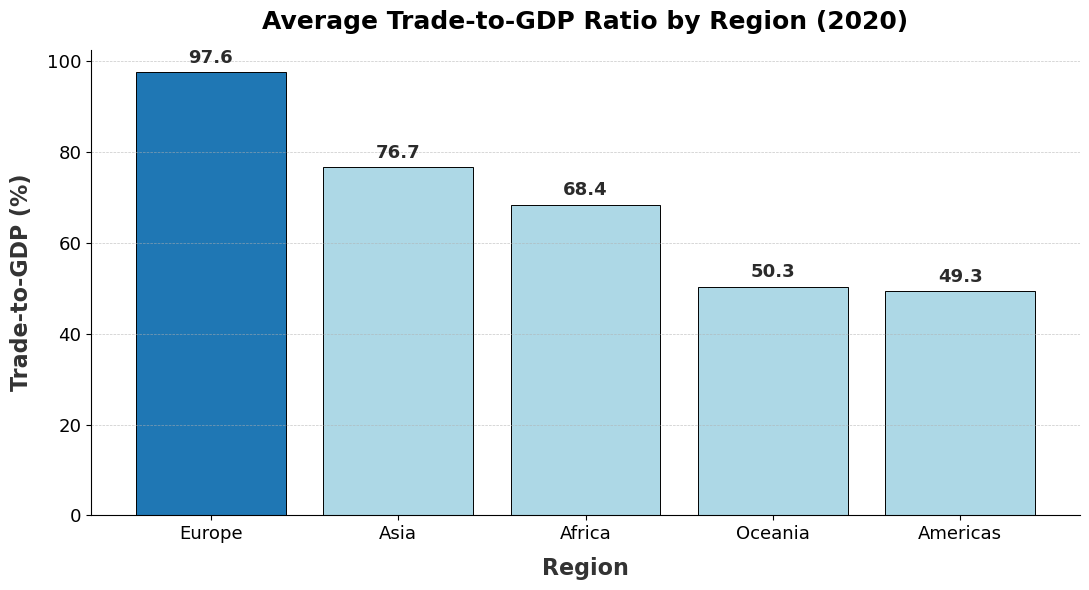

In [ ]:
import matplotlib.pyplot as plt

colors = ['#1f77b4' if region == 'Europe' else '#ADD8E6' for region in q1_region['Region_y']]

plt.figure(figsize=(11, 6))
bars = plt.bar(
    q1_region['Region_y'],
    q1_region['Trade_to_GDP'],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

plt.title(
    "Average Trade-to-GDP Ratio by Region (2020)",
    fontsize=18,
    weight='bold',
    pad=15
)

plt.xlabel(
    "Region",
    fontsize=16,
    weight='bold',
    color="#333333",
    labelpad=10
)

plt.ylabel(
    "Trade-to-GDP (%)",
    fontsize=16,
    weight='bold',
    color="#333333",
    labelpad=10
)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.2,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=13,
        weight='bold',
        color="#2b2b2b"
    )

plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# filter the data for Europe and sort the countries by Trade-to-GDP ratio in descending order
europe_countries = merged_df[merged_df["Region_y"] == "Europe"]

top_3_europe_countries = europe_countries.sort_values(by="Trade_to_GDP", ascending=False).head(3)

print(top_3_europe_countries[["Country_y", "Trade_to_GDP"]])

    Country_y  Trade_to_GDP
131  Slovenia    194.715500
130  Slovakia    190.523349
63    Hungary    188.104912


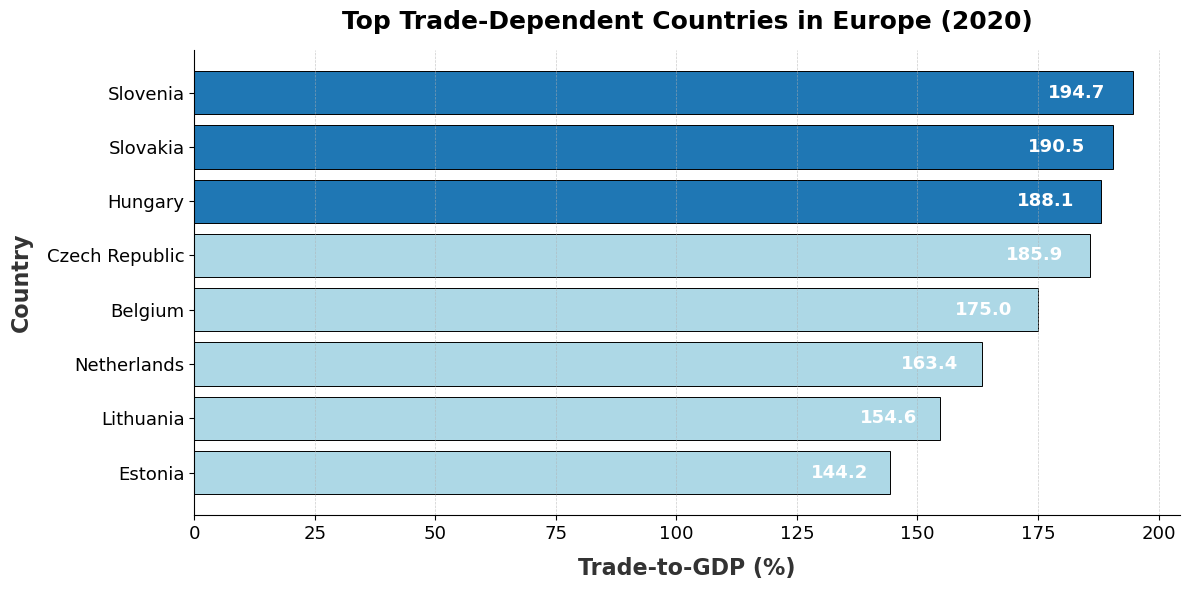

In [ ]:

# create bar chart for the top 8 trade dependent countries within Europe
region_to_show = "Europe"
region_df = merged_df[merged_df['Region_y'] == region_to_show]

region_top = (
    region_df[['Country_y', 'Trade_to_GDP']]
    .dropna()
    .drop_duplicates(subset=['Country_y'])
    .sort_values('Trade_to_GDP', ascending=False)
    .head(8)
)

plt.figure(figsize=(12, 6))

colors = ['#1f77b4' if i < 3 else '#ADD8E6' for i in range(len(region_top))]

bars = plt.barh(
    region_top['Country_y'],
    region_top['Trade_to_GDP'],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

plt.title(
    f"Top Trade-Dependent Countries in {region_to_show} (2020)",
    fontsize=18,
    weight='bold',
    pad=15
)

plt.xlabel(
    "Trade-to-GDP (%)",
    fontsize=16,
    weight='bold',
    color="#333333",
    labelpad=10
)
plt.ylabel(
    "Country",
    fontsize=16,
    weight='bold',
    color="#333333",
    labelpad=10
)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - (width * 0.03),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va='center',
        ha='right',
        fontsize=13,
        weight='bold',
        color="white"
    )

plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.65)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


### **Question 2:**
**What is the import dependency vs export dependency of the most trade dependent countries in Europe**

**Explanation:**
Exploring the import and export value to GDP value among these trade dependent countries and provide insight into their economic structure and potential economic vulnerabilities.

**Process:**
For the merged dataset, new columns were created to calculate Import-to-GDP and Export-to-GDP ratios, representing the proportion of their GDP tied to imports and exports, respectively. The data was then filtered by the top 3 trade dependent countries in Europe. Finally, a Net_Trade_Reliance metric was derived by subtracting Import-to-GDP from Export-to-GDP, enabling a clear assessment of whether each trade dependent region or country relies more on imports or exports.

**Answer:**
Based on the chart, all three countries have higher exports than imports. Slovenia has the biggest different between import and export dependency, although overall they represent relatively balanced import and export trade ratio.


In [ ]:
# Filter top trade depend countries
top_countries = ["Slovenia", "Slovakia", "Hungary"]

# Import Dependency Ratio
merged_df["Import_to_GDP"] = (merged_df["Imports_USM"] / merged_df["UN GDP ($USD, Million)"]) * 100

# Export Dependency Ratio
merged_df["Export_to_GDP"] = (merged_df["Exports_USM"] / merged_df["UN GDP ($USD, Million)"]) * 100

# Import Percentage amoung Total Trade
merged_df["Import_Percentage"]= (merged_df["Imports_USM"]/merged_df["Total_Trade_USM"])*100

# Export Percentage amoung Total Trade
merged_df["Export_Percentage"]= (merged_df["Exports_USM"]/merged_df["Total_Trade_USM"])*100


# Country-level averages for top trade-dependent countries
country_trade_profile = (
    merged_df[merged_df["Country_y"].isin(top_countries)]
    .groupby("Country_y")[["Import_to_GDP", "Export_to_GDP", "Import_Percentage","Export_Percentage"]]
    .mean()
    .assign(Net_Trade_Reliance=lambda x: x["Export_to_GDP"] - x["Import_to_GDP"])
)

print(country_trade_profile)

           Import_to_GDP  Export_to_GDP  Import_Percentage  Export_Percentage  \
Country_y                                                                       
Hungary        92.210722      95.894182          49.020901          50.979095   
Slovakia       94.010248      96.513100          49.343164          50.656836   
Slovenia       94.441669     100.273831          48.502389          51.497611   

           Net_Trade_Reliance  
Country_y                      
Hungary              3.683460  
Slovakia             2.502852  
Slovenia             5.832163  


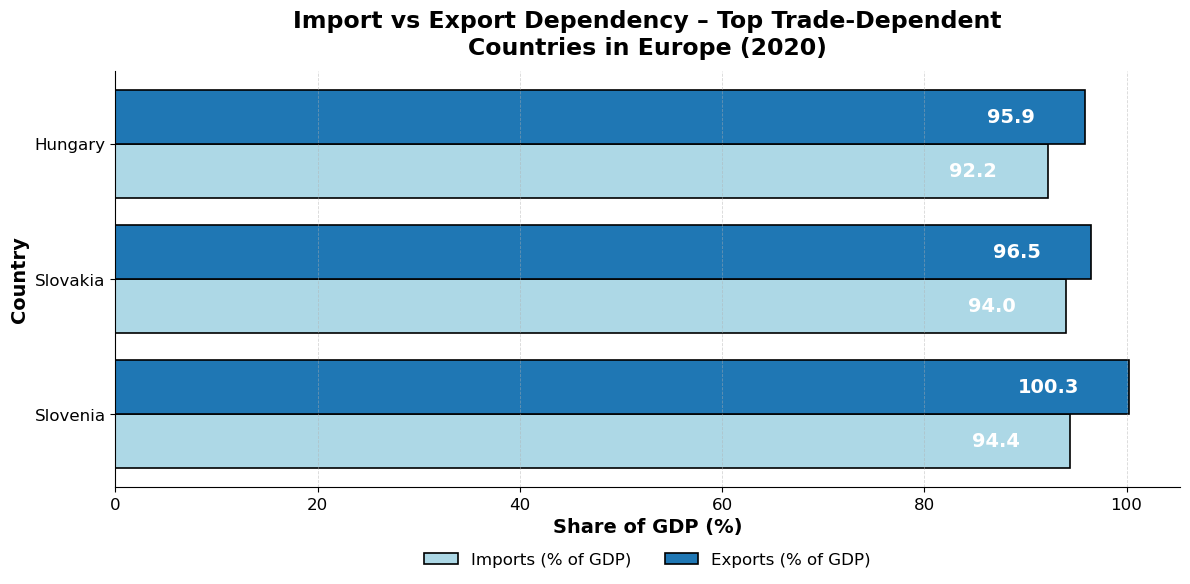

In [ ]:
# bar chart for the country of interests import and export dependency
df_q2 = country_trade_profile.sort_values("Export_to_GDP", ascending=False)

countries   = df_q2.index.tolist()
imports_pct = df_q2["Import_to_GDP"].tolist()
exports_pct = df_q2["Export_to_GDP"].tolist()

y = np.arange(len(countries))
bar_h = 0.4

plt.figure(figsize=(12, 6))

bars_import = plt.barh(
    y - bar_h/2,
    imports_pct,
    height=bar_h,
    color="#ADD8E6",
    edgecolor="black",
    linewidth=1.2,  # Thicker edge for more distinction
    label="Imports (% of GDP)"
)

bars_export = plt.barh(
    y + bar_h/2,
    exports_pct,
    height=bar_h,
    color="#1f77b4",
    edgecolor="black",
    linewidth=1.2,  # Thicker edge for more distinction
    label="Exports (% of GDP)"
)

for bar in bars_import:
    width = bar.get_width()
    plt.text(
        width - 5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="right",
        va="center",
        fontsize=14,
        color="white",
        weight="bold"
    )

for bar in bars_export:
    width = bar.get_width()
    plt.text(
        width - 5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="right",
        va="center",
        fontsize=14,
        color="white",
        weight="bold"
    )

plt.title(
    "Import vs Export Dependency – Top Trade-Dependent\nCountries in Europe (2020)",
    fontsize=17,
    weight="bold",
    pad=12
)

plt.xlabel(
    "Share of GDP (%)",
    fontsize=14,
    weight="bold"
)

plt.ylabel(
    "Country",
    fontsize=14,
    weight="bold"
)

plt.yticks(y, countries, fontsize=12)
plt.xticks(fontsize=12)

plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()


### **Question 3**
**Which product categories contribute most to import and export activity in the top three trade-dependent European economies?**

**Explanation:**
Understanding which product categories make up the majority of a country’s imports and exports helps to identify the sectors on which the economy is most reliant. This information allows policymakers to pinpoint areas that might be vulnerable to global disruptions or supply chain issues. It also aids in making informed decisions regarding trade policy, industry support, and identifying areas where economic diversification may be necessary to mitigate risk.

**Process:**
After identifying the top three European countries with the highest trade-to-GDP ratios, the import and export values for each product category were manually extracted into a new dataframe. This dataset was then merged with the previous dataframe filtered by the country found in Question 1 to ensure consistency and facilitate combined analysis. Finally, a column chart was created to compare the import and export values across product categories, helping to identify which industries each economy relies on most in terms of imports and exports.

**Answer:**

*Hungary*

In Hungary, capital goods and consumer goods dominate the trade values, with exports slightly surpassing imports, highlighting Hungary’s strength in manufacturing and export-driven industries. Raw materials account for the smallest share of trade but still show a positive export balance. Notably, intermediate goods are the only category where imports exceed exports, suggesting that Hungary relies on imported inputs for its production processes. Overall, this trade pattern indicates that Hungary’s economy is slightly more dependent on exports, particularly in higher-value goods, which is important for understanding its role in global supply chains.

*Slovakia*

Slovakia’s imports and exports by industry category in 2020 show a varied trade pattern across different sectors. Slovakia imports more than it exports in raw materials, intermediate goods, and capital goods, indicating a reliance on foreign inputs and equipment, especially in the manufacturing and production sectors. Conversely, consumer goods stand out as the only category where exports significantly exceed imports, suggesting a strong export capacity in this sector. The high import values for capital goods and intermediate goods highlight Slovakia’s dependence on imported resources and machinery, which may reflect its role as a manufacturing hub within global supply chains. Overall, the trade profile suggests that Slovakia is more import-dependent in intermediate and capital goods but benefits from strong consumer goods exports.

*Slovenia*

Slovenia’s imports and exports by industry category in 2020 show that the country has a slightly higher export value overall, with consumer goods and capital goods leading the trade volumes. Exports of consumer goods exceed imports, indicating a strong market for Slovenian-made consumer products abroad. Capital goods exports are also slightly higher than imports, reflecting a positive trade balance in this sector. However, imports surpass exports in raw materials and intermediate goods, suggesting that Slovenia relies on imported inputs to support its production processes. This pattern highlights Slovenia’s role as both a producer of finished goods and a dependent user of raw and intermediate materials, typical of an economy integrated into regional supply chains.

In [ ]:
merged_df_EU["Product Category Percentage (Import)"] = (merged_df_EU["Import Value (Millions)"]) / merged_df_EU["Imports_USM"] *100
merged_df_EU["Product Category Percentage (Export)"] = (merged_df_EU["Export Value (Millions)"]) / merged_df_EU["Exports_USM"] *100

merged_df_EU
q3import=merged_df_EU.pivot_table(values="Product Category Percentage (Import)", index="Country Name", columns="Category", aggfunc="first")
q3export = merged_df_EU.pivot_table(values="Product Category Percentage (Export)", index="Country Name", columns="Category", aggfunc="first")

print(q3import)

print(q3export)


Category      Capital goods  Consumer goods  Intermediate goods  Raw materials
Country Name                                                                  
Hungary           40.931040       28.246106           18.527053       4.151025
Slovakia          45.430308       31.977771           16.075978       6.127285
Slovenia          20.521082       39.112021           22.105456       4.594449
Category      Capital goods  Consumer goods  Intermediate goods  Raw materials
Country Name                                                                  
Hungary           41.112583       36.735606           13.817189       4.667062
Slovakia          30.362486       53.848225           13.040195       2.686987
Slovenia          20.476249       43.000123           16.728962       3.142814


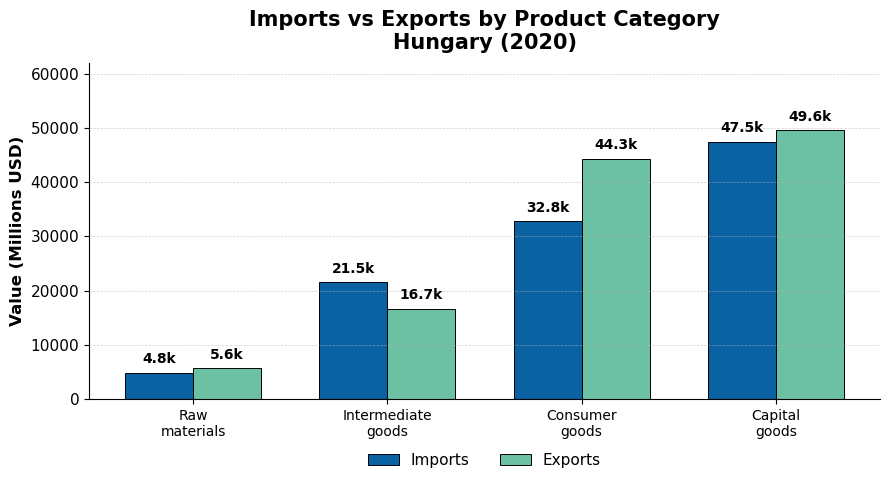

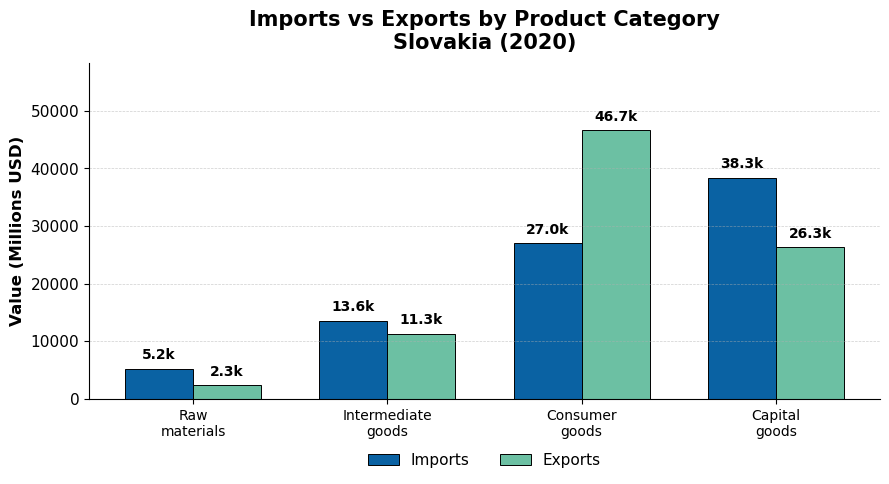

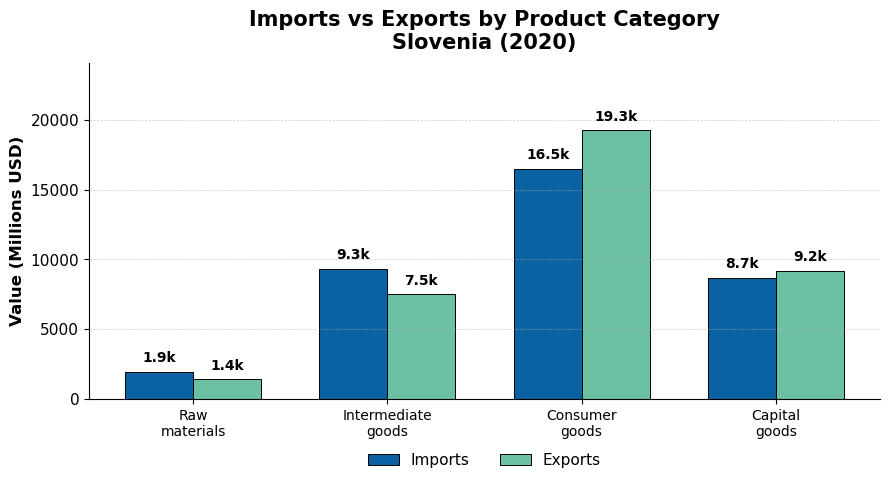

In [ ]:
# Create bar chart for Imports vs Exports by Product Category for the top three countries
countries  = ["Hungary", "Slovakia", "Slovenia"]
categories = ["Raw materials", "Intermediate goods", "Consumer goods", "Capital goods"]
x_labels   = ["Raw\nmaterials", "Intermediate\ngoods", "Consumer\ngoods", "Capital\ngoods"]

for country in countries:

    sub = (
        df_q3[df_q3["Country Name"] == country]
        .set_index("Category")
        .reindex(categories)
    )

    imports_vals = sub["Import Value (Millions)"].values
    exports_vals = sub["Export Value (Millions)"].values

    country_y_max = max(max(imports_vals), max(exports_vals)) * 1.25

    x = np.arange(len(categories))
    width = 0.35

    plt.figure(figsize=(9, 5))

    bars_import = plt.bar(
        x - width/2,
        imports_vals,
        width,
        color=COLORS["navy"],
        edgecolor="black",
        linewidth=0.7,
        label="Imports"
    )

    bars_export = plt.bar(
        x + width/2,
        exports_vals,
        width,
        color=COLORS["mint"],
        edgecolor="black",
        linewidth=0.7,
        label="Exports"
    )

    for bar in list(bars_import) + list(bars_export):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + country_y_max * 0.02,
            f"{height/1000:.1f}k",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold"
        )

    plt.title(
        f"Imports vs Exports by Product Category\n{country} (2020)",
        fontsize=15,
        weight="bold",
        pad=10
    )

    plt.ylabel("Value (Millions USD)", fontsize=12, weight="bold")
    plt.xticks(x, x_labels, fontsize=10)
    plt.yticks(fontsize=11)
    plt.ylim(0, country_y_max)

    plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        frameon=False,
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

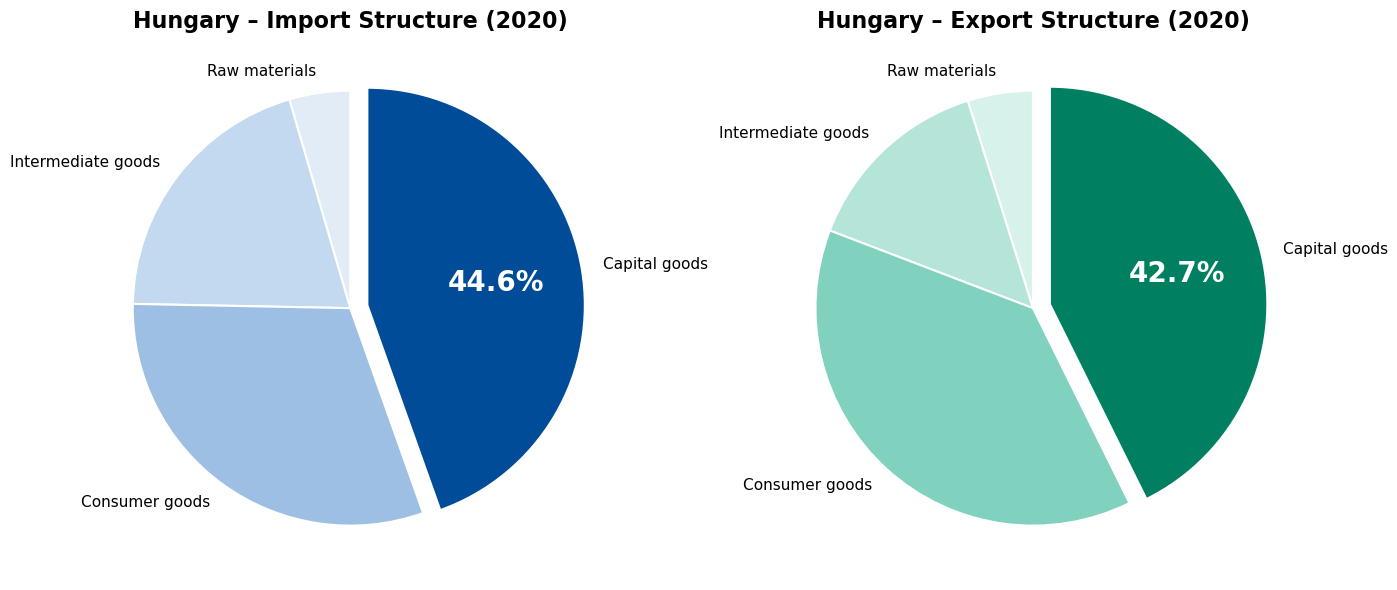

In [ ]:
# pie chart for product categories in Hungary
categories = ["Raw materials", "Intermediate goods", "Consumer goods", "Capital goods"]

imports = np.array([4816, 21495, 32771, 47488])
exports = np.array([5631, 16671, 44323, 49604])

max_imp_idx = imports.argmax()
max_exp_idx = exports.argmax()

IMPORT_MAIN   = "#004C99"
IMPORT_SHADES = ["#e1ecf7", "#c3d9ef", "#9cbfe3"]

EXPORT_MAIN   = "#008060"
EXPORT_SHADES = ["#d7f2ea", "#b4e5d8", "#80d1be"]

def assign_shaded_colors(values, main_idx, shades, main_color):
    idx_sorted = np.argsort(values)
    color_list = [""] * len(values)
    shade_i = 0
    for idx in idx_sorted:
        if idx == main_idx:
            color_list[idx] = main_color
        else:
            color_list[idx] = shades[shade_i]
            shade_i += 1
    return color_list

import_colors = assign_shaded_colors(imports, max_imp_idx, IMPORT_SHADES, IMPORT_MAIN)
export_colors = assign_shaded_colors(exports, max_exp_idx, EXPORT_SHADES, EXPORT_MAIN)

explode_imports = [0.08 if i == max_imp_idx else 0 for i in range(len(categories))]
explode_exports = [0.08 if i == max_exp_idx else 0 for i in range(len(categories))]

def autopct_main_big(values):
    max_idx = np.argmax(values)
    def inner(pct):
        inner.count += 1
        if (inner.count - 1) == max_idx:
            return f"{pct:.1f}%"
        else:
            return ""
    inner.count = 0
    return inner

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges1, texts1, autotexts1 = ax1.pie(
    imports, labels=categories, colors=import_colors, explode=explode_imports,
    startangle=90, autopct=autopct_main_big(imports),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={'fontsize': 11}
)

for autotext in autotexts1:
    if autotext.get_text() != "":
        autotext.set_fontsize(20)
        autotext.set_weight("bold")
        autotext.set_color("white")

ax1.set_title("Hungary – Import Structure (2020)", fontsize=16, weight="bold")

wedges2, texts2, autotexts2 = ax2.pie(
    exports, labels=categories, colors=export_colors, explode=explode_exports,
    startangle=90, autopct=autopct_main_big(exports),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={'fontsize': 11}
)

for autotext in autotexts2:
    if autotext.get_text() != "":
        autotext.set_fontsize(20)
        autotext.set_weight("bold")
        autotext.set_color("white")

ax2.set_title("Hungary – Export Structure (2020)", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

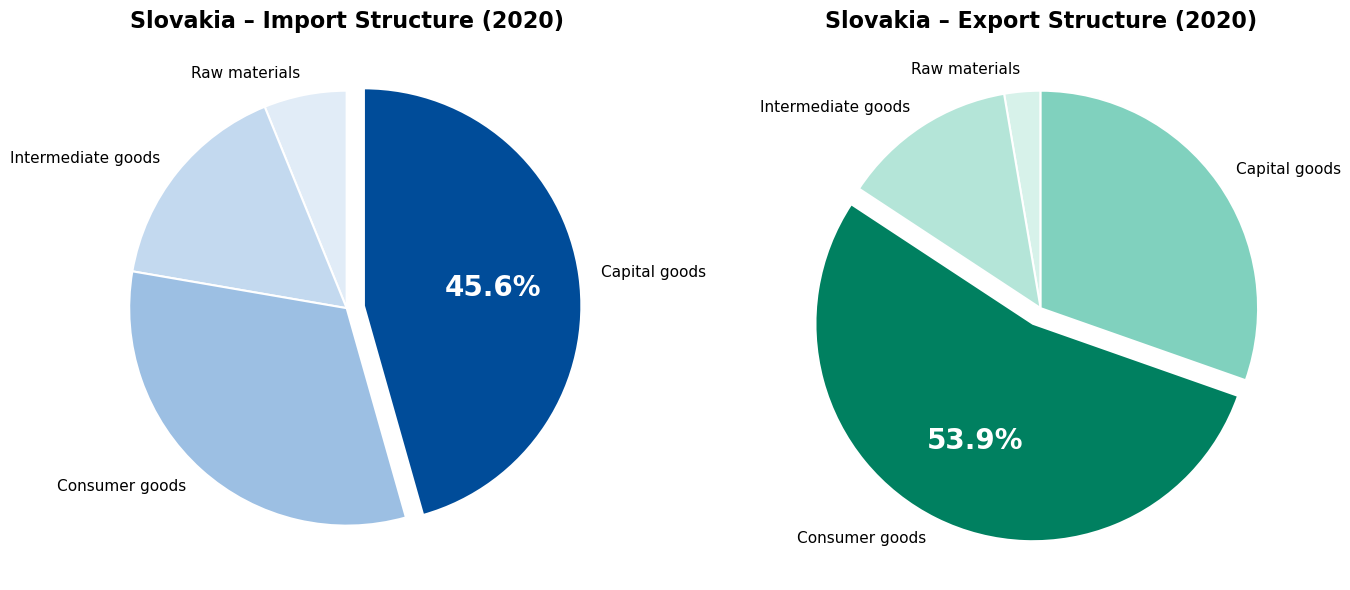

In [ ]:
# pie chart for product categories in Slovakia
categories = ["Raw materials", "Intermediate goods", "Consumer goods", "Capital goods"]

imports = np.array([5171, 13567, 26987, 38340])
exports = np.array([2328, 11298, 46654, 26306])

max_imp_idx = imports.argmax()
max_exp_idx = exports.argmax()

IMPORT_MAIN   = "#004C99"
IMPORT_SHADES = ["#e1ecf7", "#c3d9ef", "#9cbfe3"]

EXPORT_MAIN   = "#008060"
EXPORT_SHADES = ["#d7f2ea", "#b4e5d8", "#80d1be"]


def assign_shaded_colors(values, main_idx, shades, main_color):
    idx_sorted = np.argsort(values)
    color_list = [""] * len(values)
    shade_i = 0
    for idx in idx_sorted:
        if idx == main_idx:
            color_list[idx] = main_color
        else:
            color_list[idx] = shades[shade_i]
            shade_i += 1
    return color_list

import_colors = assign_shaded_colors(imports, max_imp_idx, IMPORT_SHADES, IMPORT_MAIN)
export_colors = assign_shaded_colors(exports, max_exp_idx, EXPORT_SHADES, EXPORT_MAIN)

explode_imports = [0.08 if i == max_imp_idx else 0 for i in range(len(categories))]
explode_exports = [0.08 if i == max_exp_idx else 0 for i in range(len(categories))]

def autopct_main_big(values):
    max_idx = np.argmax(values)
    def inner(pct):
        inner.count += 1
        if inner.count - 1 == max_idx:
            return f"{pct:.1f}%"
        else:
            return ""
    inner.count = 0
    return inner

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges1, texts1, autotexts1 = ax1.pie(
    imports, labels=categories, colors=import_colors, explode=explode_imports,
    startangle=90, autopct=autopct_main_big(imports),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={'fontsize': 11}
)

for autotext in autotexts1:
    if autotext.get_text() != "":
        autotext.set_fontsize(20)
        autotext.set_weight("bold")
        autotext.set_color("white")

ax1.set_title("Slovakia – Import Structure (2020)", fontsize=16, weight="bold")

wedges2, texts2, autotexts2 = ax2.pie(
    exports, labels=categories, colors=export_colors, explode=explode_exports,
    startangle=90, autopct=autopct_main_big(exports),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={'fontsize': 11}
)

for autotext in autotexts2:
    if autotext.get_text() != "":
        autotext.set_fontsize(20)
        autotext.set_weight("bold")
        autotext.set_color("white")

ax2.set_title("Slovakia – Export Structure (2020)", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

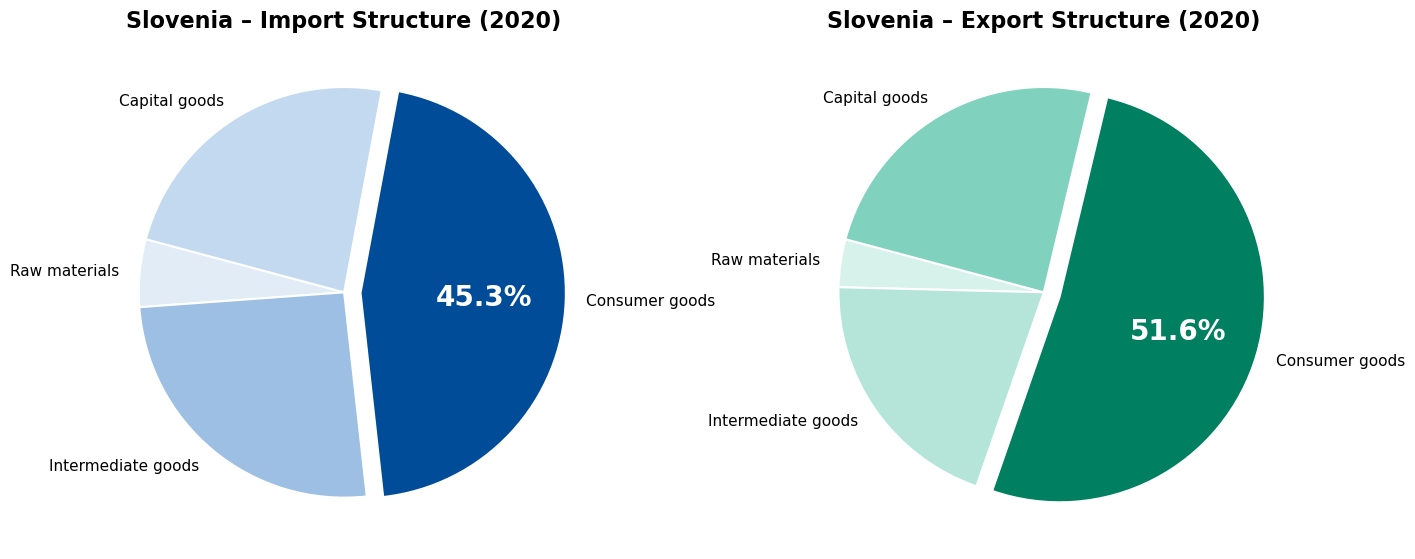

In [ ]:
# pie chart for product categories in Slovenia

categories = ["Raw materials", "Intermediate goods", "Consumer goods", "Capital goods"]

imports_si = np.array([1940, 9334, 16515, 8665])
exports_si = np.array([1409, 7500, 19278, 9180])

max_imp_idx_si = imports_si.argmax()
max_exp_idx_si = exports_si.argmax()

IMPORT_MAIN   = "#004C99"
IMPORT_SHADES = ["#e1ecf7", "#c3d9ef", "#9cbfe3"]

EXPORT_MAIN   = "#008060"
EXPORT_SHADES = ["#d7f2ea", "#b4e5d8", "#80d1be"]

def assign_shaded_colors(values, main_idx, shades, main_color):
    idx_sorted = np.argsort(values)
    colors = [""] * len(values)
    shade_i = 0
    for idx in idx_sorted:
        if idx == main_idx:
            colors[idx] = main_color
        else:
            colors[idx] = shades[shade_i]
            shade_i += 1
    return colors

import_colors_si = assign_shaded_colors(imports_si, max_imp_idx_si,
                                        IMPORT_SHADES, IMPORT_MAIN)
export_colors_si = assign_shaded_colors(exports_si, max_exp_idx_si,
                                        EXPORT_SHADES, EXPORT_MAIN)

explode_imports_si = [0.08 if i == max_imp_idx_si else 0 for i in range(len(categories))]
explode_exports_si = [0.08 if i == max_exp_idx_si else 0 for i in range(len(categories))]

def autopct_main_big(values):
    max_idx = np.argmax(values)
    def inner(pct):
        inner.count += 1
        if (inner.count - 1) == max_idx:
            return f"{pct:.1f}%"
        return ""
    inner.count = 0
    return inner

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges1, texts1, autotexts1 = ax1.pie(
    imports_si,
    labels=categories,
    colors=import_colors_si,
    explode=explode_imports_si,
    startangle=165,
    autopct=autopct_main_big(imports_si),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11}
)
for t in autotexts1:
    if t.get_text():
        t.set_fontsize(20)
        t.set_weight("bold")
        t.set_color("white")

ax1.set_title("Slovenia – Import Structure (2020)", fontsize=16, weight="bold")

wedges2, texts2, autotexts2 = ax2.pie(
    exports_si,
    labels=categories,
    colors=export_colors_si,
    explode=explode_exports_si,
    startangle=165,
    autopct=autopct_main_big(exports_si),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11}
)
for t in autotexts2:
    if t.get_text():
        t.set_fontsize(20)
        t.set_weight("bold")
        t.set_color("white")

ax2.set_title("Slovenia – Export Structure (2020)", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

### **Question 4**
**How has COVID-19 impacted the trading activity among the top trade-dependent countries?**

**Limitation:**

A recent debate has emerged after the pandemic over whether higher trade dependence increases or decreases the risk of economic vulnerability (World Trade Organisation, 2021; United Nations, 2022), which our research is unable to address due to limitations in the current dataset. The dataset used contains only annual trade and GDP data for 2020, which is insufficient to assess changes over time. To analyse the impact of COVID-19 on trading activity, time-series data showing trade values before, during, and after 2020 would be required. Without multiple years of data, it is impossible to determine trends, disruptions, or shifts in imports and exports attributable to COVID-19, meaning this question cannot be answered with the current dataset.

In addition, the analysis cannot account for the origin or destination of each country’s imports and exports. Incorporating this information could provide further insight into supply chain vulnerabilities. Countries that rely heavily on a small number of trading partners face higher risks if those partners experience political instability or supply disruptions.

**Proposed Web Scraping Solution:**

To analyse the potential impact of COVID-19 on trade activities among the top trade-dependent European countries, time-series GDP data from 2005 to 2023 were scraped from the World Bank website and transformed into a structured DataFrame. These datasets were then merged using the country codes to enable a comprehensive time-series analysis, which would help identify trends and assess how COVID-19 affected trading activities over time.

*Code Overview*

This Python code uses the `requests` library to make an API call to the World Bank, fetching GDP data for specific countries over a defined period. The fetched data is then processed and converted into a Pandas DataFrame.

*Explanation of Individual Elements and Where to Find Them on WDI*

**BASE_URL:** `"https://api.worldbank.org/v2/country/"`  
**Explanation:** This is the base endpoint for accessing country-specific data through the World Bank API. It is a standard part of their API documentation.  
**Finding on WDI:** This exact URL does not appear directly on the WDI website interface, as it is intended for programmatic access. However, it is consistent across all World Bank API calls for country data.

---

**INDICATOR_CODE:** `"NY.GDP.MKTP.CD"`  
**Explanation:** This is the unique code identifying a specific economic indicator. In this case, `"NY.GDP.MKTP.CD"` refers to GDP (current US$).  

**Finding on WDI:**  
1. Go to the World Bank Open Data website: https://data.worldbank.org/indicator  
2. Search for *GDP (current US$)*  
3. Click the indicator to open its page  
4. The indicator code appears near the title and in the URL

---

**target_countries_iso3a:** `['SVN', 'SVK', 'HUN']`  
**Explanation:** These are the three-letter ISO country codes for Slovenia, Slovakia, and Hungary.  
**Finding on WDI:**  
- Search for a country on the World Bank Open Data website  
- The ISO code appears in the URL (e.g., https://data.worldbank.org/country/SVN)  
- ISO country code lists are also accessible from official sources linked by WDI

---

**years_of_interest:** `'2005:2023'`  
**Explanation:** This defines the year range for the requested data. `'2005:2023'` means data from 2005 up to and including 2023.  
**Finding on WDI:**  
On an indicator page, data can be filtered by year using the website’s time-range controls. The API, however, uses a `start_year:end_year` format.


In [ ]:
import requests
import pandas as pd
import json

# --- Define Parameters ---
# World Bank API base URL
BASE_URL = "https://api.worldbank.org/v2/country/"
INDICATOR_CODE = "NY.GDP.MKTP.CD"

target_countries_iso3a = ['SVN', 'SVK', 'HUN']
years_of_interest = '2005:2023'

# Construct the full API URL
# The ISO 3A codes are joined by semicolons (;) in the URL
url = f"{BASE_URL}{';'.join(target_countries_iso3a)}/indicator/{INDICATOR_CODE}"
print(url)

# Define the query parameters
params = {
    'date': years_of_interest,
    'format': 'json',
    'per_page': 500
}

# 1. Make the API Request
print("Attempting to fetch time-series GDP data from World Bank API...")
try:
    response = requests.get(url, params=params)
    response.raise_for_status()

    # The World Bank API response is a list; the second element ([1]) is the data
    data = response.json()
    gdp_data_list = data[1]

    # 2. Extract Data and ISO 3A Code
    parsed_gdp = []
    if gdp_data_list:
        for record in gdp_data_list:
            if record['value'] is not None:
                parsed_gdp.append({
                    # The 'id' key of the 'country' object is the ISO 3A code
                    'Country_code': record['countryiso3code'],
                    'Country_Name': record['country']['value'],
                    'Year': record['date'],
                    'GDP_Value_USD': record['value']
                })

        df_gdp_ts = pd.DataFrame(parsed_gdp)

        # Convert GDP to millions for consistency with your initial dataset
        df_gdp_ts['GDP_Value_Million_USD'] = (df_gdp_ts['GDP_Value_USD'] / 1e6).round(2)
        df_gdp_ts = df_gdp_ts.drop(columns=['GDP_Value_USD'])

        print("\nSuccessfully fetched, parsed, and normalized GDP data.")

    else:
        print("\nNo GDP data found for the specified countries and years.")

except requests.exceptions.RequestException as e:
    print(f"\nAPI Request Failed: {e}")

# Display the first few rows of the resulting DataFrame structure
if 'df_gdp_ts' in locals():
    print("\n--- Resulting Time-Series GDP DataFrame (First 5 Rows) ---")
    print(df_gdp_ts.head())

https://api.worldbank.org/v2/country/SVN;SVK;HUN/indicator/NY.GDP.MKTP.CD
Attempting to fetch time-series GDP data from World Bank API...

Successfully fetched, parsed, and normalized GDP data.

--- Resulting Time-Series GDP DataFrame (First 5 Rows) ---
  Country_code Country_Name  Year  GDP_Value_Million_USD
0          HUN      Hungary  2023              214022.57
1          HUN      Hungary  2022              177536.70
2          HUN      Hungary  2021              183282.69
3          HUN      Hungary  2020              158468.49
4          HUN      Hungary  2019              164936.68


### **Conclusion**

This project highlights Europe’s significant role in global trade, identifying Slovenia, Slovakia, and Hungary as the most trade-dependent countries within the region. By analysing import and export values across key product categories, the study provides insights into the economic structures and trade dependencies of these nations. Although limitations in the available data prevented a detailed assessment of COVID-19’s impact on trade over time, the approach outlined offers a solid foundation for future research using time-series datasets. These findings can support European trade policymakers in developing strategies that enhance trade resilience and promote sustainable economic growth. Furthermore, this analytical method may assist countries in examining their own trade dependencies and identifying vulnerabilities within their trade portfolios.



### **Reference**
Hristanova, J. (2025). The European Union's Trade Policy Amid Rising Global Protectionism. *European Generation*. https://www.europeangeneration.eu/single-post/the-european-union-s-trade-policy-amid-rising-global-protectionism

Lebastard, L., Matani, M., & Serafini, R. (2023). Understanding the Impact of COVID-19 Supply Disruptions on Exporters in Global Value Chains. *Centre for Economic Policy Research*. https://cepr.org/voxeu/columns/understanding-impact-covid-19-supply-disruptions-exporters-global-value-chains

Organisation for Economic Co-operation and Development. (2022). *International Trade During the COVID-19 Pandemic: Big Shifts and Uncertainty*. https://www.oecd.org/content/dam/oecd/en/publications/reports/2022/03/international-trade-during-the-covid-19-pandemic-big-shifts-and-uncertainty_33e349d3/d1131663-en.pdf

Organisation for Economic Co-operation and Development. (2025). *Economic Security in a Changing World: Economic security and vulnerabilities in international supply chains*. https://www.oecd.org/en/publications/2025/09/economic-security-in-a-changing-world_78f3b129/full-report/economic-security-and-vulnerabilities-in-international-supply-chains_dc88aefa.html

United Nations. (2022). *Impact of the Covid-19 Pandemic on Trade and Development: Lessons Learned*. https://unctad.org/system/files/official-document/osg2022d1_en.pdf

World Trade Organisation. (2021). *World Trade Report 2021: Economic resilience and trade*. https://www.wto.org/english/res_e/booksp_e/wtr21_e/01_c_wtr21_e.pdf
